# IoT Intrusion Detection — Baseline: Logistic Regression

This notebook trains and evaluates the **first baseline model** on the
preprocessed splits produced by `01_preprocessing_pipeline.ipynb`.

**Why Logistic Regression first?**

- **Fast.** A linear model converges in minutes on 4M rows; we get a sanity
  check on the whole pipeline before investing in heavier models.
- **Interpretable.** Each feature gets one coefficient per class — easy to
  reason about whether the model is learning sensible patterns.
- **Strong floor.** A well-regularized LR with class weights is a respectable
  baseline for tabular intrusion detection. Anything later (RF, gradient
  boosting, NN) has to beat this number to justify its complexity.

**What this notebook produces:**

- A fitted `LogisticRegression` saved to `models/baseline/logistic_regression.joblib`.
- A metrics JSON with accuracy, macro-F1, weighted-F1, and per-class
  precision/recall/F1 for both validation and test splits.
- A row-normalized confusion matrix PNG for both splits.

**Primary metric: macro-F1.** Accuracy is misleading on this 230:1-imbalanced
dataset; macro-F1 weights every class equally so rare attacks count.

## Setup

`%autoreload 2` re-imports `src/` modules whenever they change on disk — so
edits to `src/evaluation.py` take effect on the next cell run without a kernel
restart.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.linear_model import SGDClassifier

from src.config import BASELINE_DIR, RANDOM_STATE
from src.data_pipeline import load_artifacts, load_split
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "logistic_regression"

## 1. Load the preprocessor artifacts and the splits

The preprocessor and label encoder were fit during preprocessing and saved
to `models/preprocessing/`. The transformed splits live under
`data/processed/splits/`. We load both — no recomputation here, no risk of
drift between this notebook and the preprocessing one.

`load_split` returns three things per split:
- `X` — transformed features (already imputed, power-transformed, scaled)
- `y_str` — class names as strings (e.g. `"DDoS-ICMP_Flood"`)
- `y_enc` — integer labels from the LabelEncoder

We train on `y_str` because the `class_weights` dict from preprocessing has
string keys, so they line up directly.

In [2]:

artifacts = load_artifacts()
X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  _ = load_split("test")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

X_train: (4086646, 47)   y_train: (4086646,)
X_val:   (875710, 47)   y_val:   (875710,)
X_test:  (875710, 47)   y_test:  (875710,)
Classes: 34


## 2. Configure the model

We use `SGDClassifier(loss="log_loss")` — this is **logistic regression
trained via stochastic gradient descent** instead of the closed-form lbfgs
solver. The model is identical (same loss, same L2 penalty, same predictions);
only the optimizer differs.

**Why SGD instead of lbfgs?** lbfgs needs to materialize a dense
`(n_samples, n_classes)` array of class probabilities — for our 4M-row train
split with 34 classes, that's `4,086,646 × 34 × 8 = 1.04 GB` per buffer, and
lbfgs allocates several. On a typical 8–16 GB laptop this OOMs. SGD streams
the data in mini-batches and never materializes that matrix, so memory peaks
at a few hundred MB.

Parameters:

- **`loss="log_loss"`** — gives logistic-regression behavior (cross-entropy,
  in the multi-class case via one-vs-rest).
- **`penalty="l2"`** with **`alpha=1e-4`** — sklearn's default L2 strength
  for SGD. Note: `alpha` is *not* the same as LR's `C` — they are related by
  `alpha ≈ 1 / (C · n_samples)`.
- **`learning_rate="optimal"`** — sklearn's adaptive schedule based on the
  regularization strength. Robust default.
- **`max_iter=20`** — at most 20 epochs (one epoch = one pass through the
  training data). With early stopping, usually exits earlier.
- **`early_stopping=True`** with **`validation_fraction=0.1`** and
  **`n_iter_no_change=3`** — sklearn carves out 10% of the training data as
  an internal validation set and stops when macro accuracy stops improving
  for 3 consecutive epochs. Prevents wasted compute and slight overfitting.
- **`tol=1e-3`** — early-stopping tolerance. Looser than the LR default
  (`1e-4`) because SGD's per-step noise makes very tight tolerances brittle.
- **`class_weight=artifacts.class_weights`** — same balanced weights computed
  during preprocessing. Each row's loss contribution is multiplied by
  `w_{y_i} = N / (K · n_{y_i})`, so rare attacks count proportionally more.
- **`n_jobs=-1`** — parallelizes across the 34 binary OvR classifiers.
- **`random_state=RANDOM_STATE`** — reproducible mini-batch shuffles.

**Expected fit time:** ~2–8 minutes on 4M rows, depending on the machine and
how early early-stopping kicks in. Memory peaks well under 1 GB.

In [3]:
model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    learning_rate="optimal",
    max_iter=20,
    tol=1e-3,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
    class_weight=artifacts.class_weights,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",20
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


## 3. Fit on the training split

Watch for two things in the printout below:

- **Iterations used vs. `max_iter`** — if SGD ran the full 20 epochs without
  early-stopping kicking in, the model may not have converged; consider
  raising `max_iter` and re-fitting.
- **Train accuracy** — sanity check only, not a performance metric. What
  matters is the validation result in the next step.

In [4]:
with timed("Training (SGD log_loss, OvR, 4M rows)"):
    model.fit(X_train, y_train)

n_iter = int(np.atleast_1d(model.n_iter_).max())
print(f"Epochs used:    {n_iter} / {model.max_iter}")
print(f"Train accuracy: {model.score(X_train, y_train):.4f}")

Training (SGD log_loss, OvR, 4M rows): 39.3s
Epochs used:    4 / 20
Train accuracy: 0.7091


## 4. Evaluate on the validation split

Validation is for **model selection** — comparing this LR against future
models, choosing hyperparameters, deciding whether to invest in something
heavier. The test set stays untouched until the final evaluation.

Metrics returned by `evaluate()`:

- **accuracy** — fraction of correct predictions. Reported for completeness
  but **not the primary metric** under heavy class imbalance.
- **macro-F1** — average F1 across all 34 classes equally. **This is the
  primary metric.** A model that ignores rare attacks gets penalized as
  hard as one that ignores common ones.
- **weighted-F1** — average F1 weighted by class size. Tells you how the
  model performs on a *typical* row of traffic.

In [5]:

val_metrics = evaluate(model, X_val, y_val, artifacts.label_encoder, split_name="val")

print(f"Validation results ({val_metrics.n_rows:,} rows):")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro-F1    = {val_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {val_metrics.weighted_f1:.4f}")

Validation results (875,710 rows):
  accuracy    = 0.7085
  macro-F1    = 0.5090   (primary)
  weighted-F1 = 0.7106


## 5. Per-class report

Sorted by F1 ascending, so the **worst-performing classes are at the top**.
Look here for:

- **Rare attacks with low recall** — the model isn't catching them. Class
  weights help but can't conjure information that isn't there. May need
  more data or feature engineering.
- **Confusable class pairs** — if precision is high but recall is low (or
  vice versa) on a class, it's getting mistaken for something else.
- **Sanity check** — `BenignTraffic` should be high precision (false alarms
  are bad) and reasonable recall.

In [6]:

per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0025,0.1223,0.0049,188.0000
Recon-PingSweep,0.0056,0.4041,0.0110,339.0000
Backdoor_Malware,0.0091,0.1387,0.0170,483.0000
XSS,0.0214,0.0173,0.0192,577.0000
SqlInjection,0.0237,0.1753,0.0418,787.0000
BrowserHijacking,0.0297,0.1286,0.0482,879.0000
CommandInjection,0.0401,0.1813,0.0657,811.0000
Recon-OSScan,0.1435,0.0676,0.0919,"14,739.0000"
DictionaryBruteForce,0.1772,0.1838,0.1804,"1,959.0000"
Recon-PortScan,0.2671,0.1391,0.1829,"12,342.0000"


## 6. Confusion matrix on validation

Row-normalized so each row sums to 1.0 — the **diagonal shows per-class
recall** directly. Off-diagonal entries reveal which classes get confused
with which (e.g. `DDoS-SYN_Flood` ↔ `DoS-SYN_Flood` is a likely confusion).

Saved to `models/baseline/logistic_regression_confusion_val.png`.

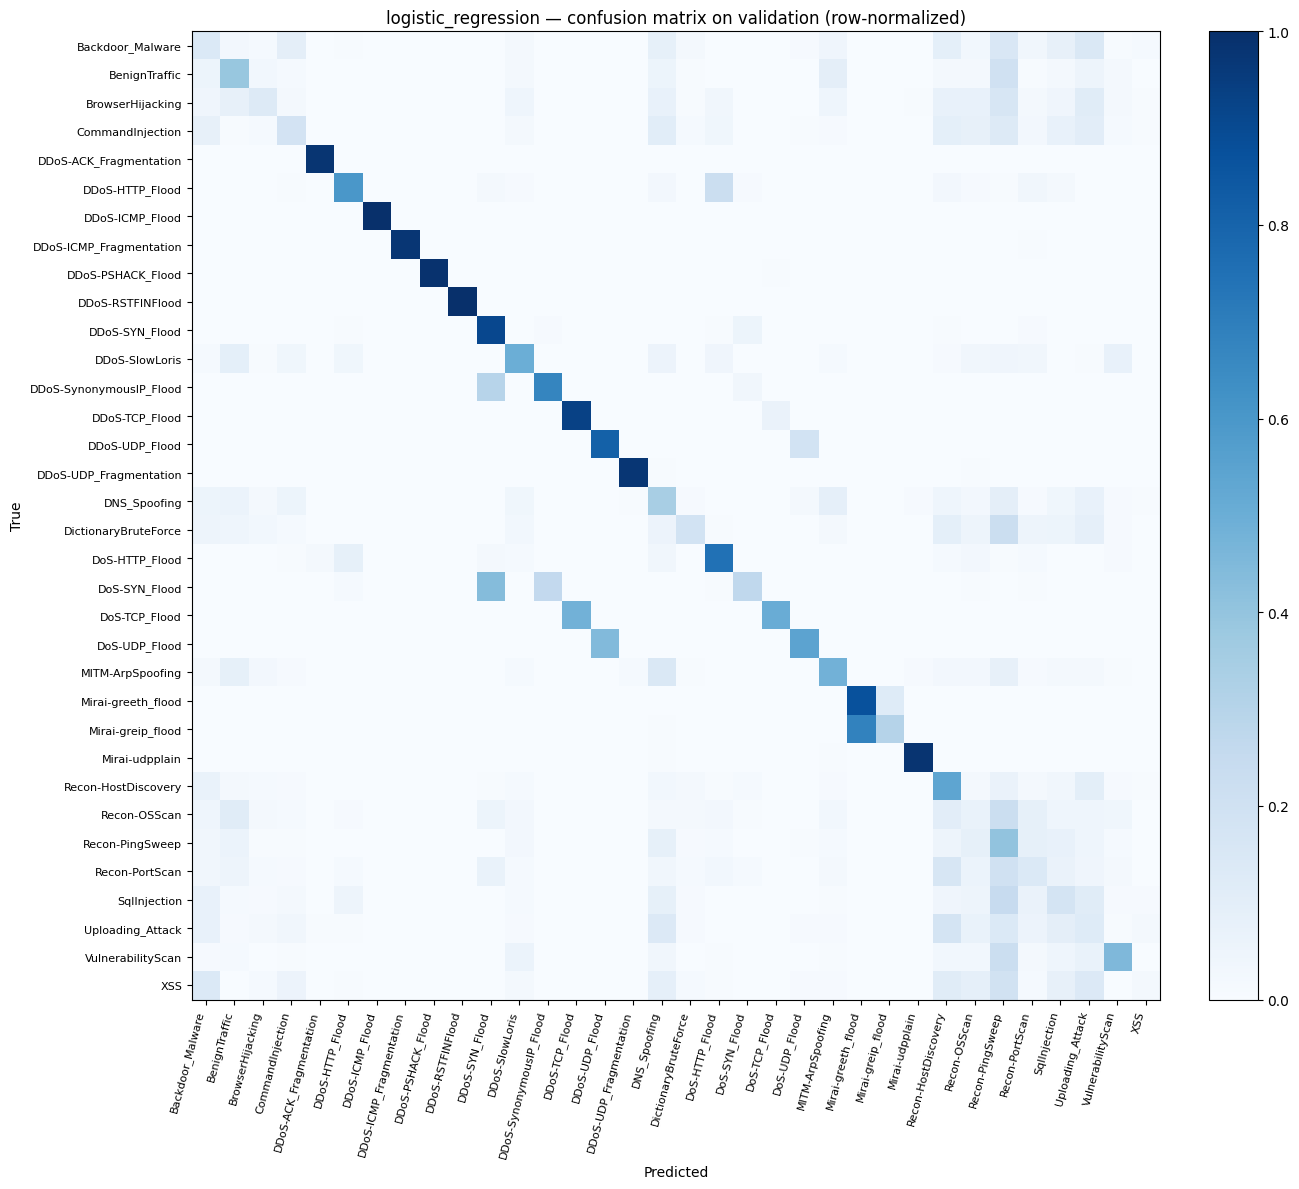

In [7]:

plot_confusion_matrix(
    model, X_val, y_val, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on validation (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 7. Final test-set evaluation

The test set is the **honest, unbiased estimate** of how the model performs
on unseen traffic. We touch it once, here, after every other decision has
been made on val. If you go back and tune the model based on the test number,
that number is no longer honest.

In [8]:

test_metrics = evaluate(model, X_test, y_test, artifacts.label_encoder, split_name="test")

print(f"Test results ({test_metrics.n_rows:,} rows):")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro-F1    = {test_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {test_metrics.weighted_f1:.4f}")

# val vs test diff — large gaps indicate overfitting on the train split
print(f"\nval → test macro-F1 delta: {test_metrics.macro_f1 - val_metrics.macro_f1:+.4f}")

Test results (875,710 rows):
  accuracy    = 0.7085
  macro-F1    = 0.5099   (primary)
  weighted-F1 = 0.7106

val → test macro-F1 delta: +0.0010


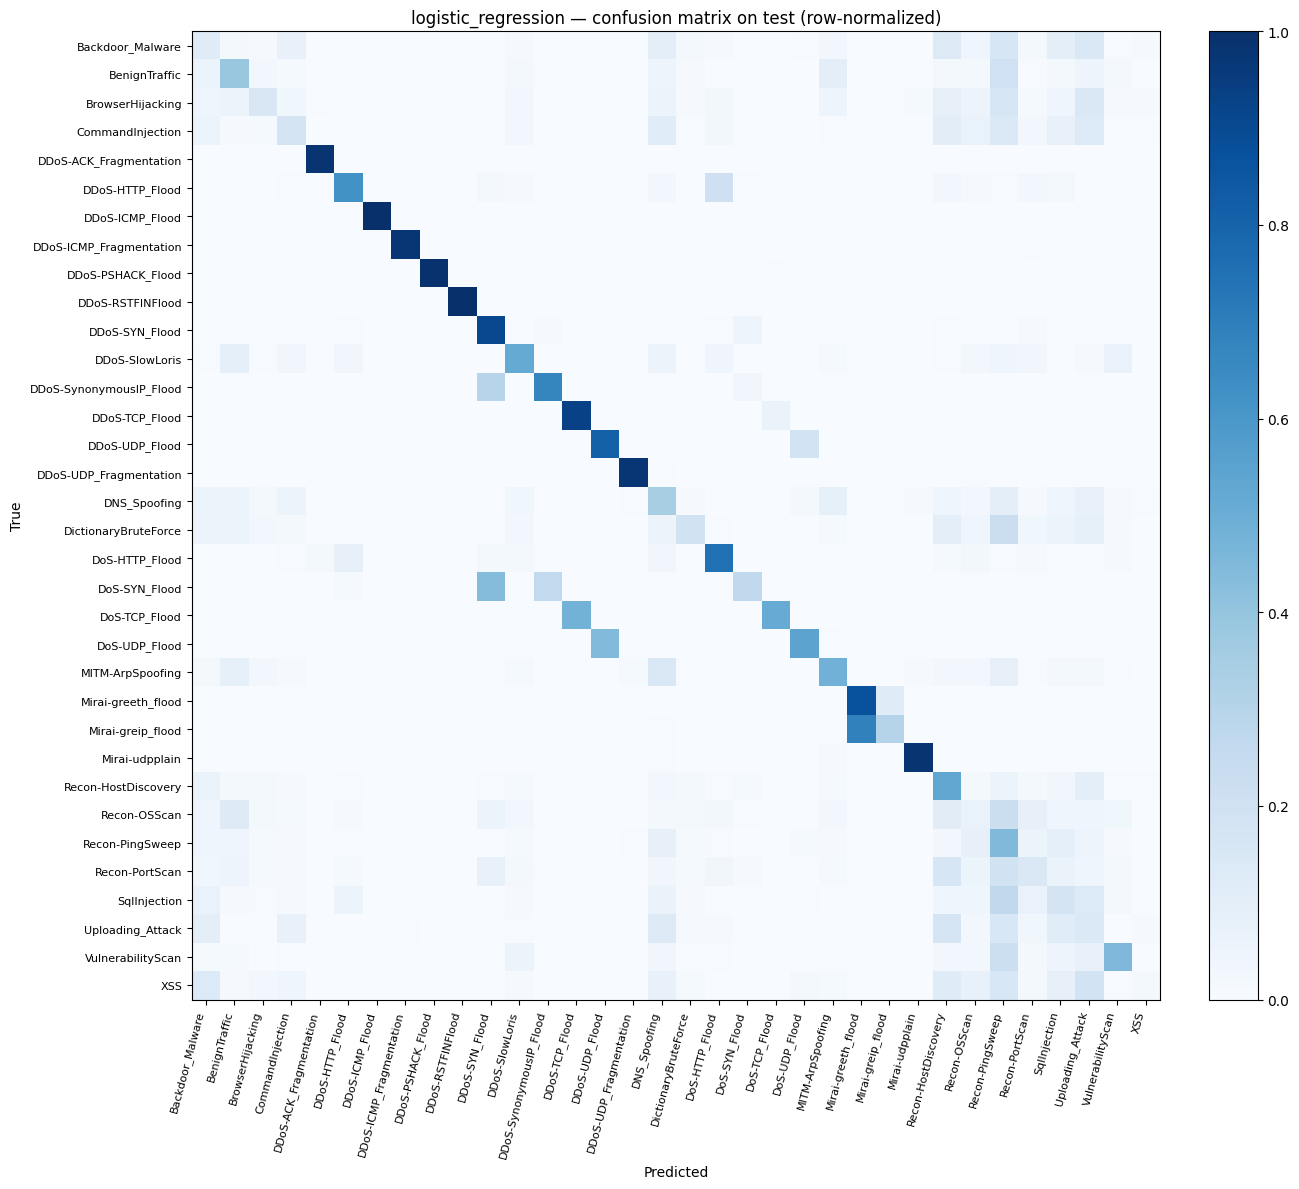

In [9]:

plot_confusion_matrix(
    model, X_test, y_test, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on test (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 8. Persist the baseline

Saves three things under `models/baseline/`:

- `logistic_regression.joblib` — the fitted model, ready to load and predict.
- `logistic_regression_metrics.json` — both val and test metrics, including
  the full per-class breakdown.
- `logistic_regression_confusion_{val,test}.png` — already saved above.

Future model notebooks (RF, gradient boosting, ...) follow the same pattern
so all baselines are directly comparable.

In [10]:

output_dir = save_baseline(model, [val_metrics, test_metrics], name=MODEL_NAME)

print(f"Saved to {output_dir}:")
for p in sorted(output_dir.glob(f"{MODEL_NAME}*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name}   ({size_kb:,.1f} KB)")

Saved to C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\models\baseline:
  logistic_regression.joblib   (18.7 KB)
  logistic_regression_confusion_test.png   (167.4 KB)
  logistic_regression_confusion_val.png   (167.8 KB)
  logistic_regression_metrics.json   (12.9 KB)
